<a href="https://colab.research.google.com/github/arman-hossain45/Deep_Learning_Lab/blob/main/lab_01_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TensorFlow Conv2D Layer

The `Conv2D` layer applies a set of learnable filters (kernels) to an input image or feature map.

## Syntax

```python
tf.keras.layers.Conv2D(
    filters,
    kernel_size,
    strides=(1, 1),
    padding='valid',
    activation=None,
)

# Convolution with Noisy Image

In [ ]:
import tensorflow as tf
import numpy as np

# Create sample input
x = np.random.rand(1, 32, 32, 3).astype(np.float32)

# Conv2D layer
conv = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
)

# Forward pass
y = conv(x)

print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : (1, 32, 32, 3)
Output shape: (1, 32, 32, 16)


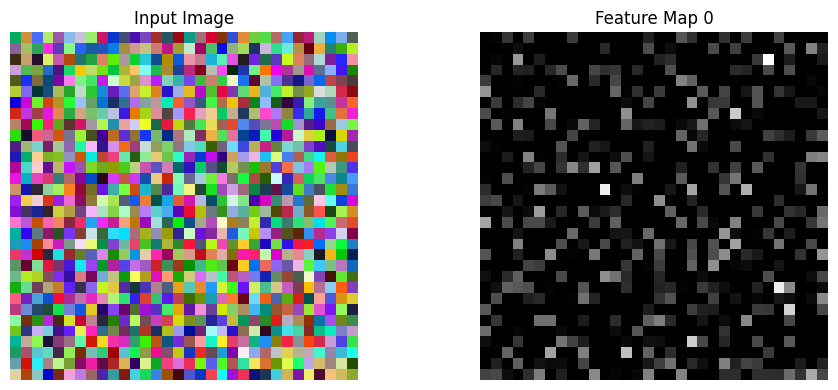

In [ ]:
import matplotlib.pyplot as plt

# Visualization
plt.figure(figsize=(10, 4))

# Input image (first RGB channel)
plt.subplot(1, 2, 1)
plt.imshow(x[0])
plt.title("Input Image")
plt.axis('off')

# Output feature map from first filter
plt.subplot(1, 2, 2)
plt.imshow(y[0, :, :, 0], cmap='gray')
plt.title("Feature Map 0")
plt.axis('off')

plt.tight_layout()
plt.show()

# With a Single Image

In [ ]:
from PIL import Image
from urllib.request import urlopen

# Example image URL
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

# Read image from URL
img = Image.open(urlopen(url)).convert("RGB")

# Resize for simplicity
img = img.resize((128, 128))

# Convert to numpy array and normalize
x = np.array(img, dtype=np.float32) / 255.0

# Add batch dimension
x = np.expand_dims(x, axis=0)

print("Input shape:", x.shape)

# Conv2D layer
conv = tf.keras.layers.Conv2D(
    filters=8,
    kernel_size=(3, 3),
    padding="same",
    activation="relu"
)

y = conv(x)

print("Output shape:", y.shape)


Input shape: (1, 128, 128, 3)
Output shape: (1, 128, 128, 8)


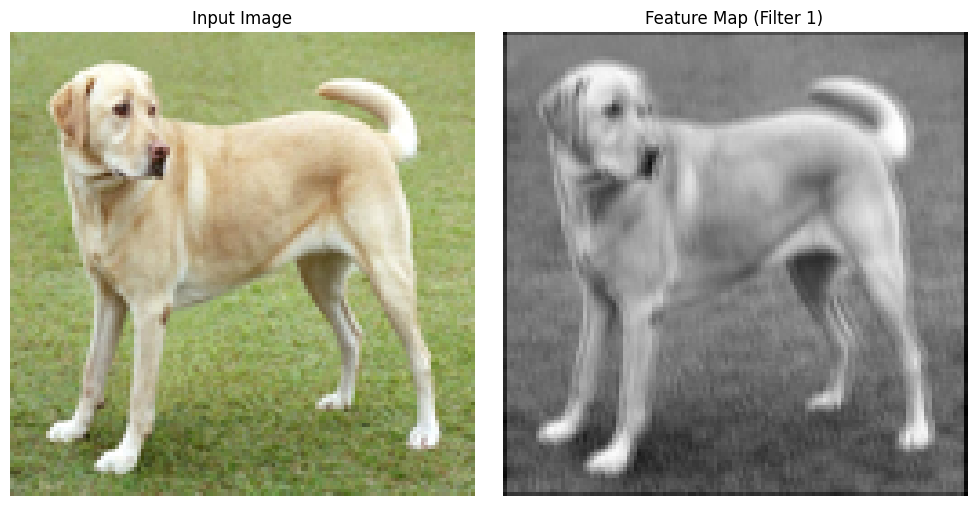

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(x[0])
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y[0, :, :, 3], cmap="gray")
plt.title("Feature Map (Filter 1)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Exploring Kernel

In CNNs, a **kernel (filter)** is a small matrix that slides over an image.

Different kernels emphasize different visual patterns:

| Kernel Type | Effect |
|------------|---------|
| Identity | Original image |
| Blur | Smooths image |
| Sharpen | Enhances details |
| Edge Detection | Highlights edges |
| Emboss | Creates 3D-like effect |

The convolution operation is:

\[
Output(i,j)=\sum_{m}\sum_{n}Image(i+m,j+n)\times Kernel(m,n)
\]

Change the kernel values below and observe how the output image changes.

In [ ]:
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

img = Image.open(urlopen(url)).convert("L")  # grayscale
img = img.resize((256, 256))

x = np.array(img, dtype=np.float32)


In [ ]:
kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

In [ ]:
image_tensor = tf.convert_to_tensor(
    x.reshape(1, x.shape[0], x.shape[1], 1),
    dtype=tf.float32
)

kernel_tensor = tf.convert_to_tensor(
    kernel.reshape(3, 3, 1, 1),
    dtype=tf.float32
)

In [ ]:
y = tf.nn.conv2d(
    image_tensor,
    kernel_tensor,
    strides=1,
    padding="SAME"
)

output = y.numpy()[0, :, :, 0]

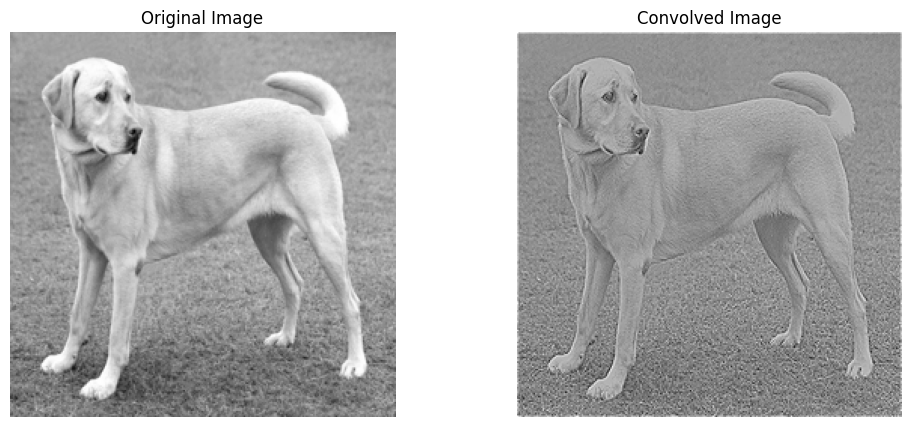

Kernel Used:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(x, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(output, cmap="gray")
axes[1].set_title("Convolved Image")
axes[1].axis("off")

plt.show()

print("Kernel Used:")
print(kernel)

### Try These Kernels

#### Identity

```python
kernel = np.array([
    [0,0,0],
    [0,1,0],
    [0,0,0]
], dtype=np.float32)
```

#### Blur

```python
kernel = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.float32) / 9
```

#### Sharpen

```python
kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
], dtype=np.float32)
```

#### Edge Detection

```python
kernel = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
], dtype=np.float32)
```

#### Emboss

```python
kernel = np.array([
    [-2,-1,0],
    [-1, 1,1],
    [ 0, 1,2]
], dtype=np.float32)
```



# Convolution Network

In [ ]:
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

img = Image.open(urlopen(url)).convert("RGB")
img = img.resize((256, 256))

x = np.array(img, dtype=np.float32) / 255.0
x = np.expand_dims(x, axis=0)

In [ ]:
conv1 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    padding="same",
    activation="relu"
)

pool1 = tf.keras.layers.MaxPooling2D(pool_size=2)

conv2 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    padding="same",
    activation="relu"
)

pool2 = tf.keras.layers.MaxPooling2D(pool_size=2)

conv3 = tf.keras.layers.Conv2D(
    filters=1,
    kernel_size=3,
    padding="same",
    activation="relu"
)

layer0 = x

layer1 = conv1(layer0)
layer2 = pool1(layer1)

layer3 = conv2(layer2)
layer4 = pool2(layer3)

layer5 = conv3(layer4)

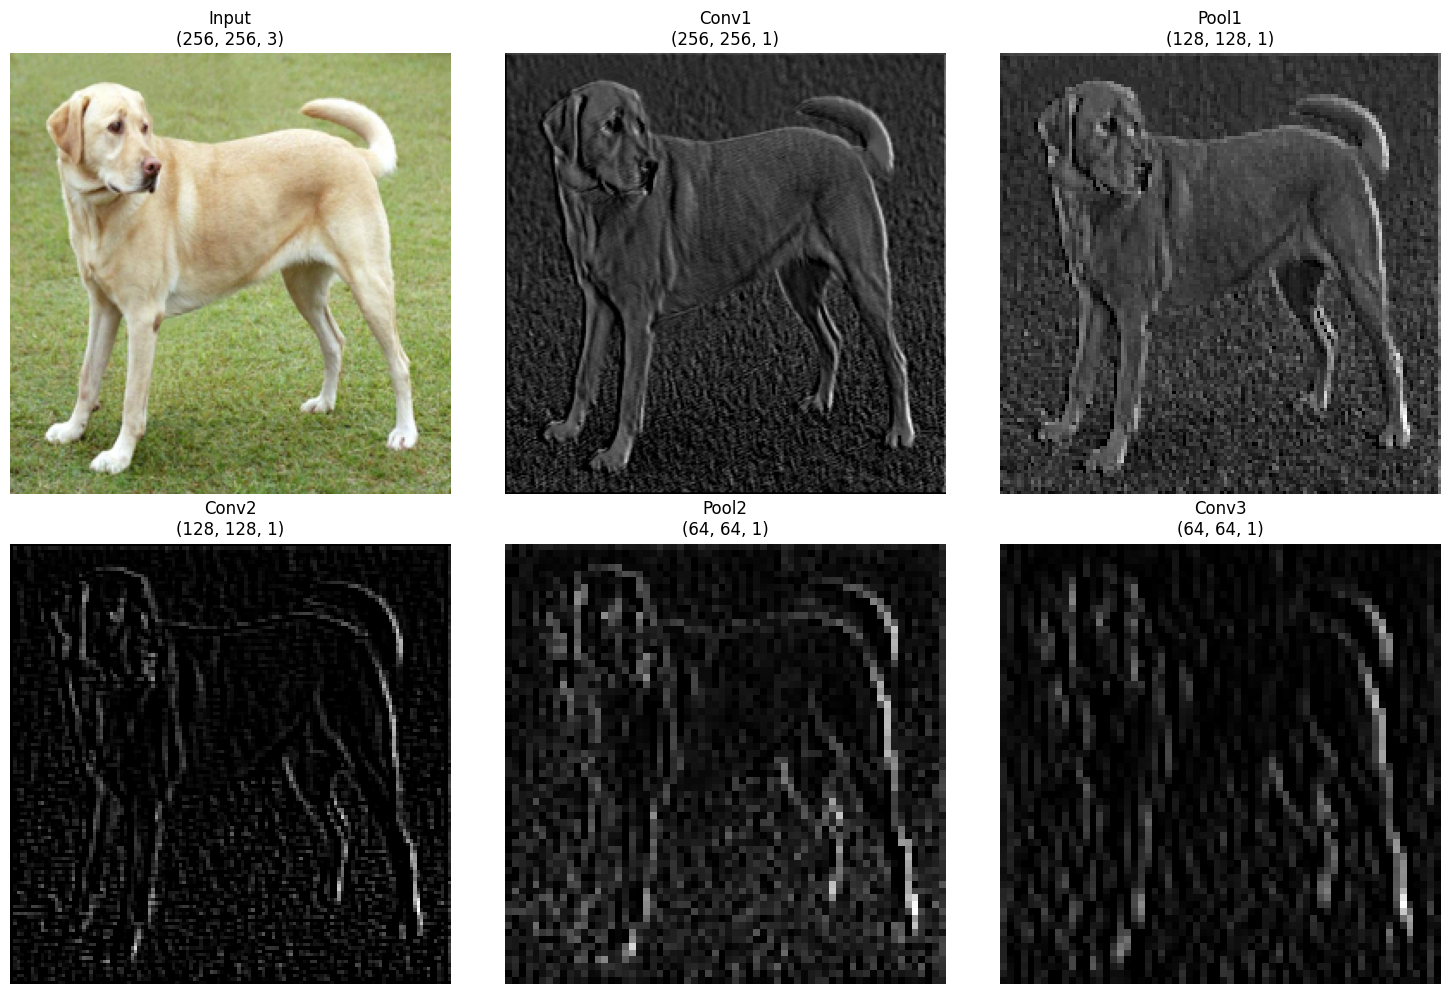

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original RGB image
axes[0,0].imshow(layer0[0])
axes[0,0].set_title(f"Input\n{layer0.shape[1:]}")
axes[0,0].axis("off")

# Conv1
axes[0,1].imshow(layer1[0,:,:,0], cmap="gray")
axes[0,1].set_title(f"Conv1\n{layer1.shape[1:]}")
axes[0,1].axis("off")

# Pool1
axes[0,2].imshow(layer2[0,:,:,0], cmap="gray")
axes[0,2].set_title(f"Pool1\n{layer2.shape[1:]}")
axes[0,2].axis("off")

# Conv2
axes[1,0].imshow(layer3[0,:,:,0], cmap="gray")
axes[1,0].set_title(f"Conv2\n{layer3.shape[1:]}")
axes[1,0].axis("off")

# Pool2
axes[1,1].imshow(layer4[0,:,:,0], cmap="gray")
axes[1,1].set_title(f"Pool2\n{layer4.shape[1:]}")
axes[1,1].axis("off")

# Conv3
axes[1,2].imshow(layer5[0,:,:,0], cmap="gray")
axes[1,2].set_title(f"Conv3\n{layer5.shape[1:]}")
axes[1,2].axis("off")

plt.tight_layout()
plt.show()

# Train a Convolution Neural Network

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize images (0-1 range)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Class names
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model = tf.keras.Sequential([

    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Block 3
    tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 74s 93ms/step - accuracy: 0.4738 - loss: 1.4660 - val_accuracy: 0.5811 - val_loss: 1.1745
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.6356 - loss: 1.0304 - val_accuracy: 0.6282 - val_loss: 1.0519
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.7034 - loss: 0.8494 - val_accuracy: 0.6998 - val_loss: 0.8641
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.7442 - loss: 0.7363 - val_accuracy: 0.7098 - val_loss: 0.8462
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.7744 - loss: 0.6466 - val_accuracy: 0.7225 - val_loss: 0.8301
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 96ms/step - accuracy: 0.7981 - loss: 0.5808 - val_accuracy: 0.7262 - val_loss: 0.8213
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.8224 - loss: 0.5067 - val_accuracy: 0.7457 - val_loss: 0.7611
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.8444 - loss: 0.4435 - 

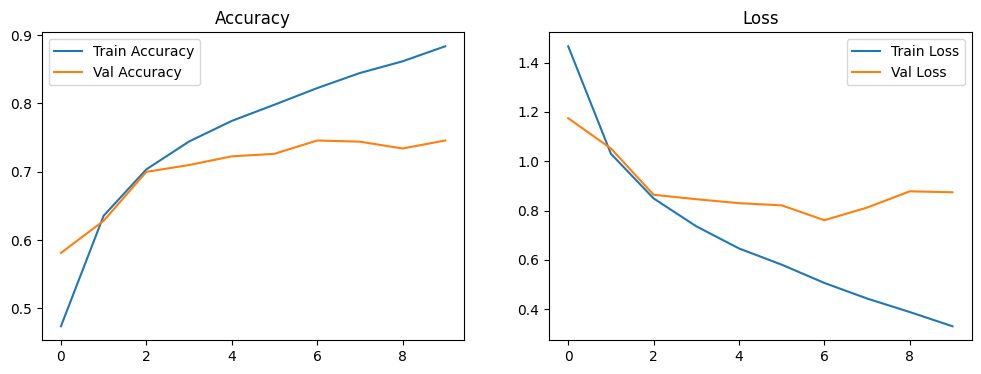

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


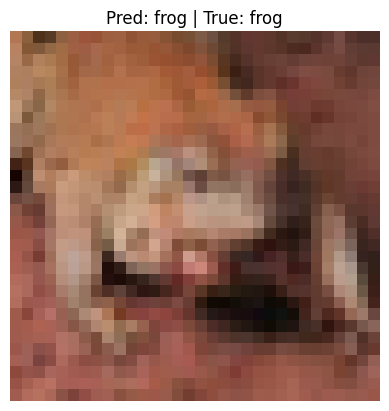

In [ ]:
import numpy as np

idx = 5
img = x_test[idx]

pred = model.predict(img.reshape(1,32,32,3))
pred_class = np.argmax(pred)

plt.imshow(img)
plt.title(f"Pred: {class_names[pred_class]} | True: {class_names[y_test[idx][0]]}")
plt.axis("off")
plt.show()

# Inspecting Convolution layer by layer

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

In [ ]:
inputs = tf.keras.Input(shape=(32,32,3))

x = tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same", name="conv1")(inputs)
x = tf.keras.layers.MaxPooling2D((2,2), name="pool1")(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same", name="conv2")(x)
x = tf.keras.layers.MaxPooling2D((2,2), name="pool2")(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same", name="conv3")(x)
x = tf.keras.layers.MaxPooling2D((2,2), name="pool3")(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(10, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.1)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 94ms/step - accuracy: 0.4673 - loss: 1.4785 - val_accuracy: 0.6080 - val_loss: 1.1020
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6327 - loss: 1.0463 - val_accuracy: 0.6614 - val_loss: 0.9789
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.6929 - loss: 0.8771 - val_accuracy: 0.7088 - val_loss: 0.8371


In [ ]:
layer_outputs = [model.get_layer("conv1").output,
                 model.get_layer("pool1").output,
                 model.get_layer("conv2").output,
                 model.get_layer("pool2").output,
                 model.get_layer("conv3").output]

activation_model = tf.keras.Model(inputs=model.input, outputs=layer_outputs)

In [ ]:
img = x_test[0]
img_input = np.expand_dims(img, axis=0)

activations = activation_model.predict(img_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [ ]:
def plot_feature_map(feature_map, title):
    plt.figure(figsize=(4,4))
    plt.imshow(feature_map[0,:,:,0], cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

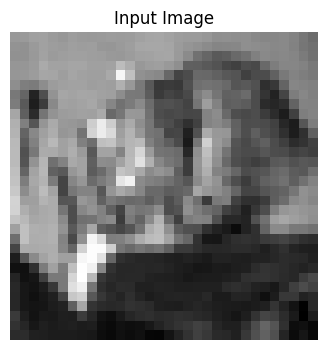

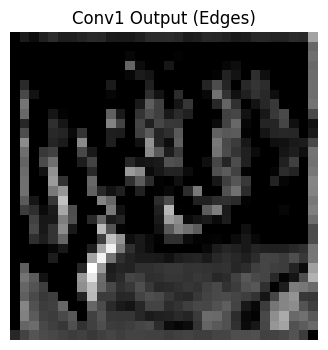

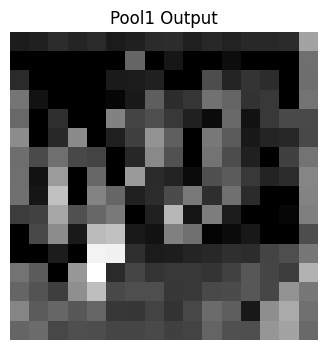

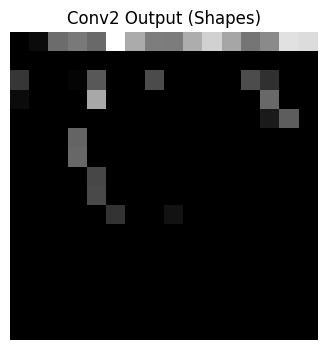

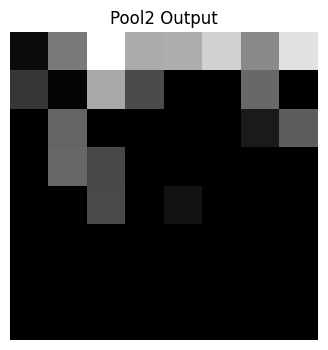

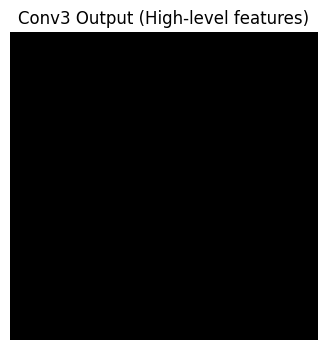

In [ ]:
plot_feature_map(img_input, "Input Image")
plot_feature_map(activations[0], "Conv1 Output (Edges)")
plot_feature_map(activations[1], "Pool1 Output")
plot_feature_map(activations[2], "Conv2 Output (Shapes)")
plot_feature_map(activations[3], "Pool2 Output")
plot_feature_map(activations[4], "Conv3 Output (High-level features)")